# EDA flags TCP - RT-IoT2022

Notebook de análisis de variables relacionadas con el estado de conexiones TCP.

In [8]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ZIP_PATH = "../rt-iot2022.zip"  # usar "data/rt-iot2022.zip" si el notebook está en la raíz
INTERNAL_FILE = "RT_IOT2022"
OUTPUT_DIR = "../docs/figures_flags_tcp"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("Archivos dentro del ZIP:", z.namelist())
    with z.open(INTERNAL_FILE) as f:
        df = pd.read_csv(f, index_col=0)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
df.head()

Archivos dentro del ZIP: ['RT_IOT2022']
Filas: 123117
Columnas: 84


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


## Variables asignadas

Se revisan FIN, SYN, RST, ACK, PSH, URG, CWR y ECE. PSH y URG aparecen separados por dirección (`fwd` y `bwd`).

In [10]:
flags_tcp = [
    "flow_FIN_flag_count",
    "flow_SYN_flag_count",
    "flow_RST_flag_count",
    "flow_ACK_flag_count",
    "fwd_PSH_flag_count",
    "bwd_PSH_flag_count",
    "fwd_URG_flag_count",
    "bwd_URG_flag_count",
    "flow_CWR_flag_count",
    "flow_ECE_flag_count",
]

flags_encontradas = [c for c in flags_tcp if c in df.columns]
flags_faltantes = [c for c in flags_tcp if c not in df.columns]

print("Flags encontradas:", flags_encontradas)
print("Flags faltantes:", flags_faltantes)

flags_tcp = flags_encontradas
for c in flags_tcp:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

Flags encontradas: ['flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'flow_ACK_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count']
Flags faltantes: []


In [11]:
# Distribución de Attack_type
class_counts = df["Attack_type"].value_counts()
class_counts

,count
Attack_type,
DOS_SYN_Hping,94659
Thing_Speak,8108
ARP_poisioning,7750
MQTT_Publish,4146
NMAP_UDP_SCAN,2590
NMAP_XMAS_TREE_SCAN,2010
NMAP_OS_DETECTION,2000
NMAP_TCP_scan,1002
DDOS_Slowloris,534


In [12]:
# Distribución general de cada flag
descripcion_flags = df[flags_tcp].describe().T
descripcion_flags

,count,mean,std,min,25%,50%,75%,max
flow_FIN_flag_count,123117.0,0.115605,0.475013,0.0,0.0,0.0,0.0,10.0
flow_SYN_flag_count,123117.0,0.950868,0.474262,0.0,1.0,1.0,1.0,8.0
flow_RST_flag_count,123117.0,0.796454,0.436998,0.0,1.0,1.0,1.0,10.0
flow_ACK_flag_count,123117.0,2.677737,41.654868,0.0,1.0,1.0,1.0,11772.0
fwd_PSH_flag_count,123117.0,0.351332,3.951627,0.0,0.0,0.0,0.0,864.0
bwd_PSH_flag_count,123117.0,0.393634,6.007443,0.0,0.0,0.0,0.0,1446.0
fwd_URG_flag_count,123117.0,0.016293,0.126602,0.0,0.0,0.0,0.0,1.0
bwd_URG_flag_count,123117.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
flow_CWR_flag_count,123117.0,0.001007,0.044689,0.0,0.0,0.0,0.0,4.0
flow_ECE_flag_count,123117.0,0.000699,0.031471,0.0,0.0,0.0,0.0,4.0


In [13]:
# Conteos de valores por flag
for col in flags_tcp:
    print("\n" + "="*70)
    print(f"Distribución de {col}")
    display(df[col].value_counts().sort_index())


Distribución de flow_FIN_flag_count


,count
flow_FIN_flag_count,
0,115053
1,2495
2,5368
3,43
4,44
5,36
6,36
7,38
8,2



Distribución de flow_SYN_flag_count


,count
flow_SYN_flag_count,
0,16791
1,95755
2,10435
3,114
4,15
5,3
6,3
8,1



Distribución de flow_RST_flag_count


...

,count
bwd_URG_flag_count,
0,123117



Distribución de flow_CWR_flag_count


,count
flow_CWR_flag_count,
0,123046
1,25
2,40
3,5
4,1



Distribución de flow_ECE_flag_count


,count
flow_ECE_flag_count,
0,123045
1,61
2,9
3,1
4,1


In [14]:
# Ceros y no ceros
zero_summary = pd.DataFrame({
    "variable": flags_tcp,
    "ceros": [(df[c] == 0).sum() for c in flags_tcp],
    "no_ceros": [(df[c] != 0).sum() for c in flags_tcp],
    "porcentaje_ceros": [round((df[c] == 0).mean() * 100, 2) for c in flags_tcp],
    "porcentaje_no_ceros": [round((df[c] != 0).mean() * 100, 2) for c in flags_tcp],
}).sort_values("porcentaje_ceros", ascending=False)

zero_summary

,variable,ceros,no_ceros,porcentaje_ceros,porcentaje_no_ceros
7,bwd_URG_flag_count,123117,0,100.00,0.00
8,flow_CWR_flag_count,123046,71,99.94,0.06
9,flow_ECE_flag_count,123045,72,99.94,0.06
6,fwd_URG_flag_count,121111,2006,98.37,1.63
0,flow_FIN_flag_count,115053,8064,93.45,6.55
5,bwd_PSH_flag_count,113159,9958,91.91,8.09
4,fwd_PSH_flag_count,110612,12505,89.84,10.16
2,flow_RST_flag_count,26553,96564,21.57,78.43
3,flow_ACK_flag_count,22543,100574,18.31,81.69
1,flow_SYN_flag_count,16791,106326,13.64,86.36


In [15]:
# Comparación por Attack_type: promedio y presencia
mean_attack_type = df.groupby("Attack_type")[flags_tcp].mean().round(4)
presence_attack_type = df.groupby("Attack_type")[flags_tcp].apply(lambda x: (x != 0).mean() * 100).round(2)

display(mean_attack_type)
display(presence_attack_type)

,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,flow_ACK_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count
Attack_type,,,,,,,,,,
ARP_poisioning,0.4317,0.4885,0.1708,12.0378,1.9538,2.4702,0.000,0.0,0.0000,0.000
DDOS_Slowloris,1.5449,2.0150,0.4551,9.5655,2.9532,1.1292,0.000,0.0,0.0000,0.000
DOS_SYN_Hping,0.0000,1.0000,0.8976,0.8976,0.0000,0.0000,0.000,0.0,0.0000,0.000
MQTT_Publish,0.0111,1.9969,0.9959,17.4503,2.9920,3.7487,0.000,0.0,0.0000,0.000
Metasploit_Brute_Force_SSH,1.4865,1.5676,0.0270,21.4595,5.0270,4.2162,0.000,0.0,0.0000,0.000
NMAP_FIN_SCAN,0.9286,0.0714,0.0000,0.3571,0.0357,0.0357,0.000,0.0,0.0000,0.000
NMAP_OS_DETECTION,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.000,0.0,0.0000,0.000
NMAP_TCP_scan,0.0000,1.0010,0.9980,1.0100,0.0040,0.0000,0.000,0.0,0.0000,0.000
NMAP_UDP_SCAN,0.0544,0.1093,0.0529,0.3247,0.1066,0.0008,0.000,0.0,0.0000,0.000


,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,flow_ACK_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count
Attack_type,,,,,,,,,,
ARP_poisioning,22.04,24.40,11.95,23.45,22.45,22.12,0.0,0.0,0.00,0.00
DDOS_Slowloris,45.51,99.06,45.51,97.94,97.94,28.09,0.0,0.0,0.00,0.00
DOS_SYN_Hping,0.00,100.00,89.76,89.76,0.00,0.00,0.0,0.0,0.00,0.00
MQTT_Publish,0.87,99.81,99.59,99.98,99.73,99.64,0.0,0.0,0.00,0.00
Metasploit_Brute_Force_SSH,75.68,78.38,2.70,78.38,78.38,75.68,0.0,0.0,0.00,0.00
NMAP_FIN_SCAN,89.29,3.57,0.00,3.57,3.57,3.57,0.0,0.0,0.00,0.00
NMAP_OS_DETECTION,0.00,0.00,100.00,100.00,0.00,0.00,0.0,0.0,0.00,0.00
NMAP_TCP_scan,0.00,99.80,99.80,100.00,0.20,0.00,0.0,0.0,0.00,0.00
NMAP_UDP_SCAN,5.37,5.48,5.29,5.37,5.37,0.08,0.0,0.0,0.00,0.00


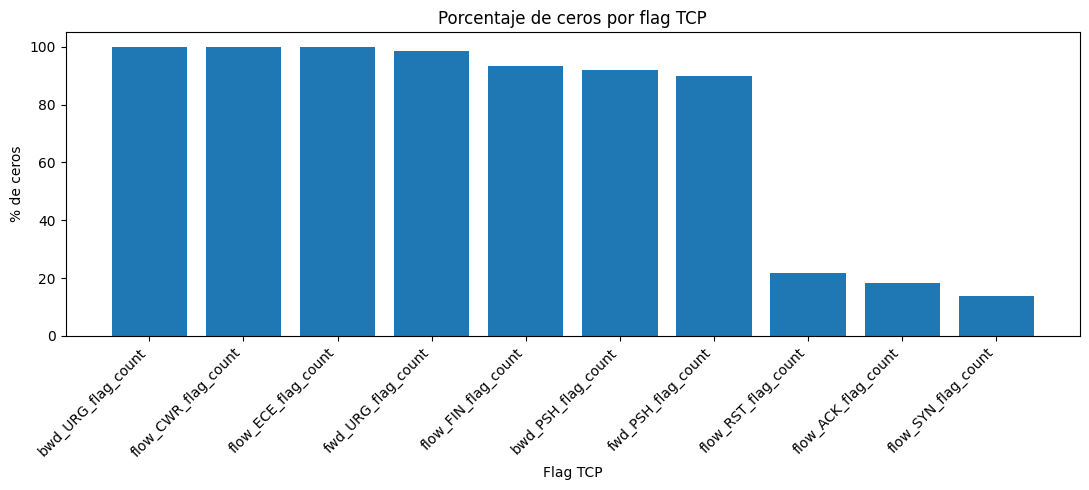

In [16]:
# Gráfica: porcentaje de ceros
plt.figure(figsize=(11, 5))
plt.bar(zero_summary["variable"], zero_summary["porcentaje_ceros"])
plt.title("Porcentaje de ceros por flag TCP")
plt.xlabel("Flag TCP")
plt.ylabel("% de ceros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ceros_flags_tcp.png"), dpi=300)
plt.show()

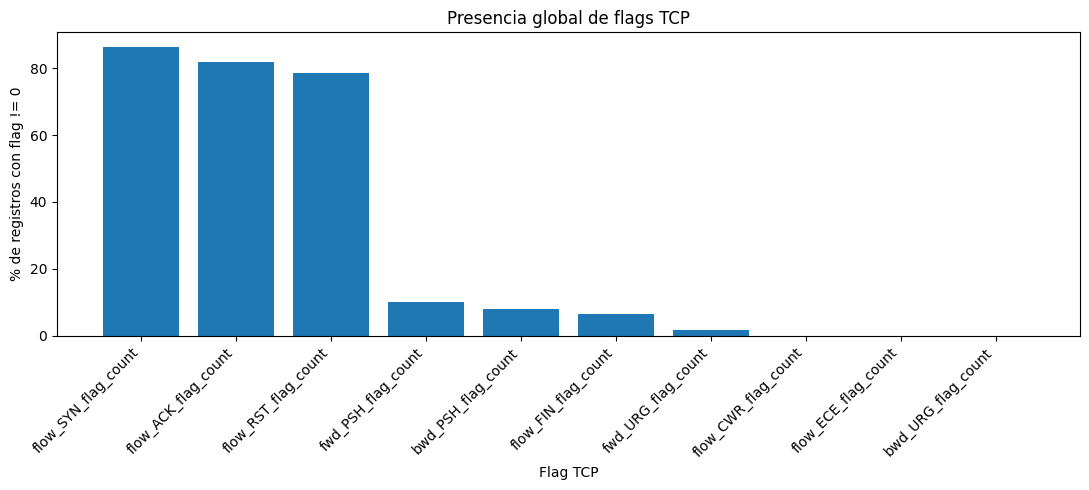

In [17]:
# Gráfica: presencia global
plot_df = zero_summary.sort_values("porcentaje_no_ceros", ascending=False)
plt.figure(figsize=(11, 5))
plt.bar(plot_df["variable"], plot_df["porcentaje_no_ceros"])
plt.title("Presencia global de flags TCP")
plt.xlabel("Flag TCP")
plt.ylabel("% de registros con flag != 0")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "presencia_global_flags_tcp.png"), dpi=300)
plt.show()

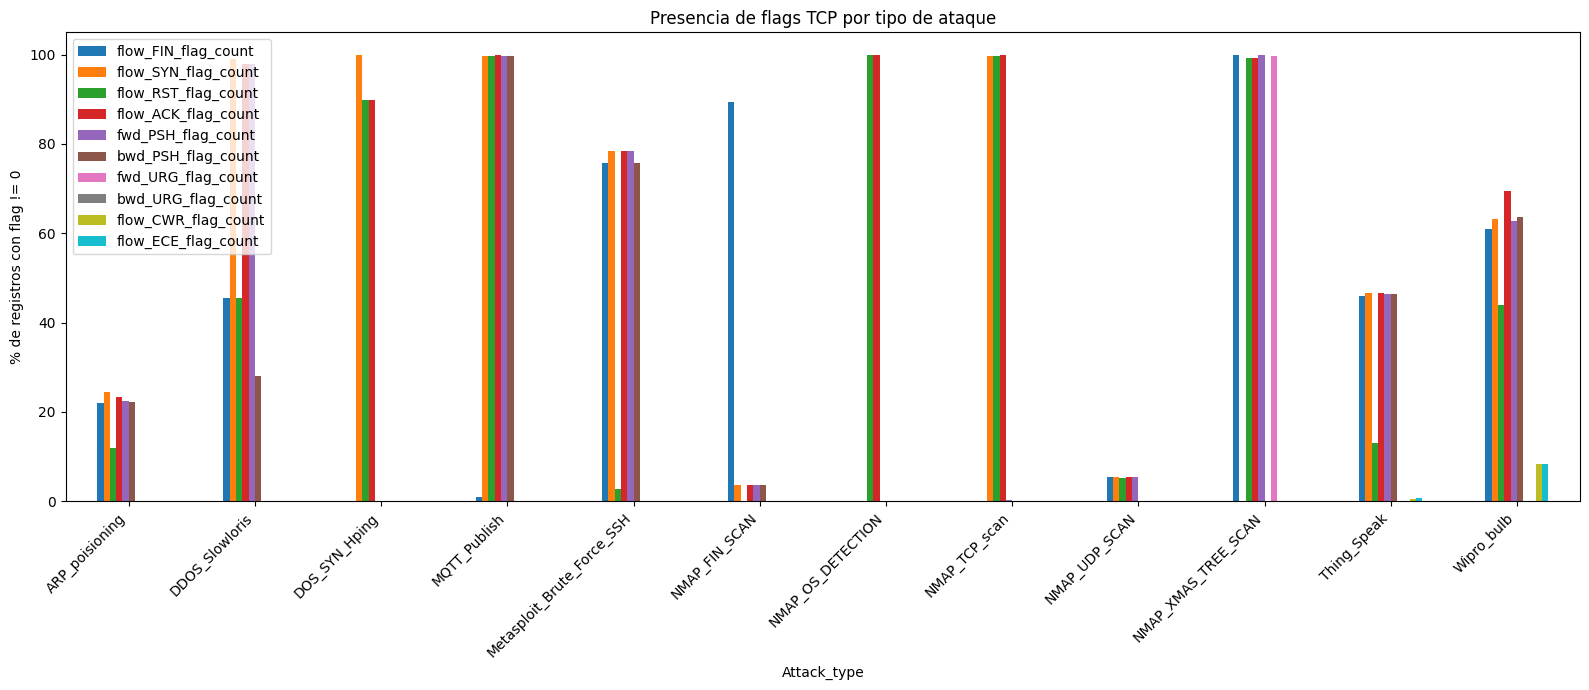

In [18]:
# Gráfica: presencia por tipo de ataque
presence_attack_type.plot(kind="bar", figsize=(16, 7))
plt.title("Presencia de flags TCP por tipo de ataque")
plt.xlabel("Attack_type")
plt.ylabel("% de registros con flag != 0")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "presencia_flags_por_attack_type.png"), dpi=300)
plt.show()

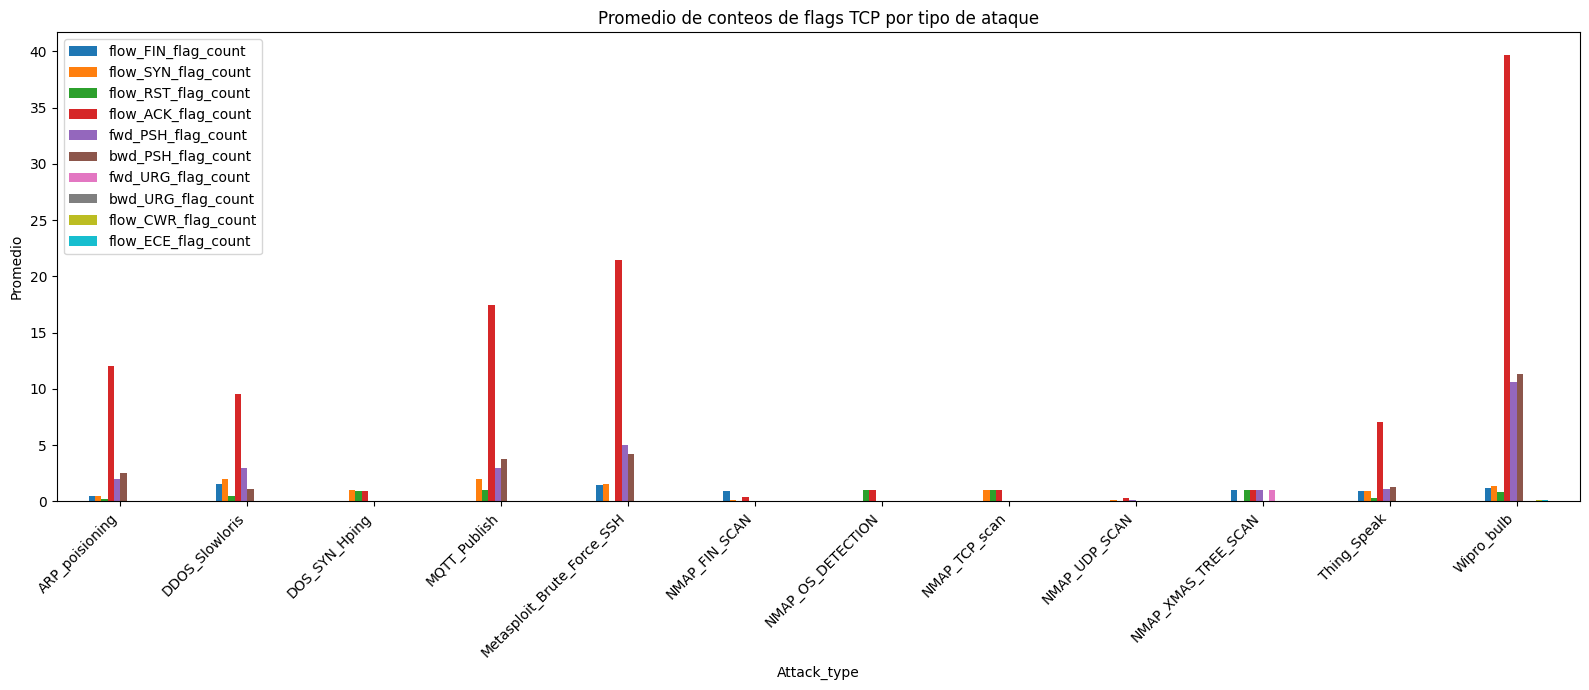

In [19]:
# Gráfica: promedio por tipo de ataque
mean_attack_type.plot(kind="bar", figsize=(16, 7))
plt.title("Promedio de conteos de flags TCP por tipo de ataque")
plt.xlabel("Attack_type")
plt.ylabel("Promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "promedio_flags_por_attack_type.png"), dpi=300)
plt.show()

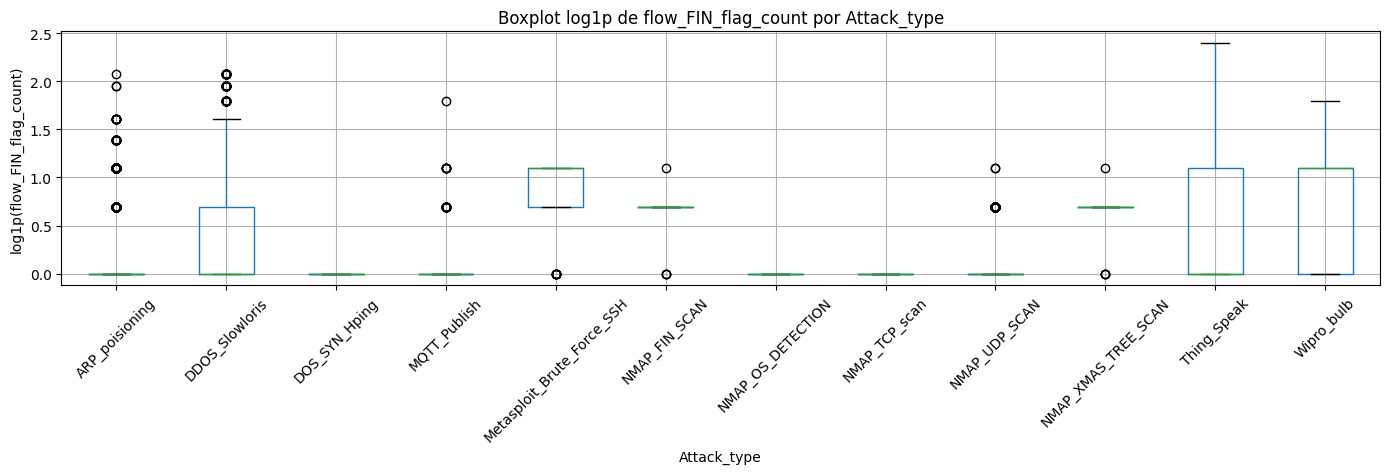

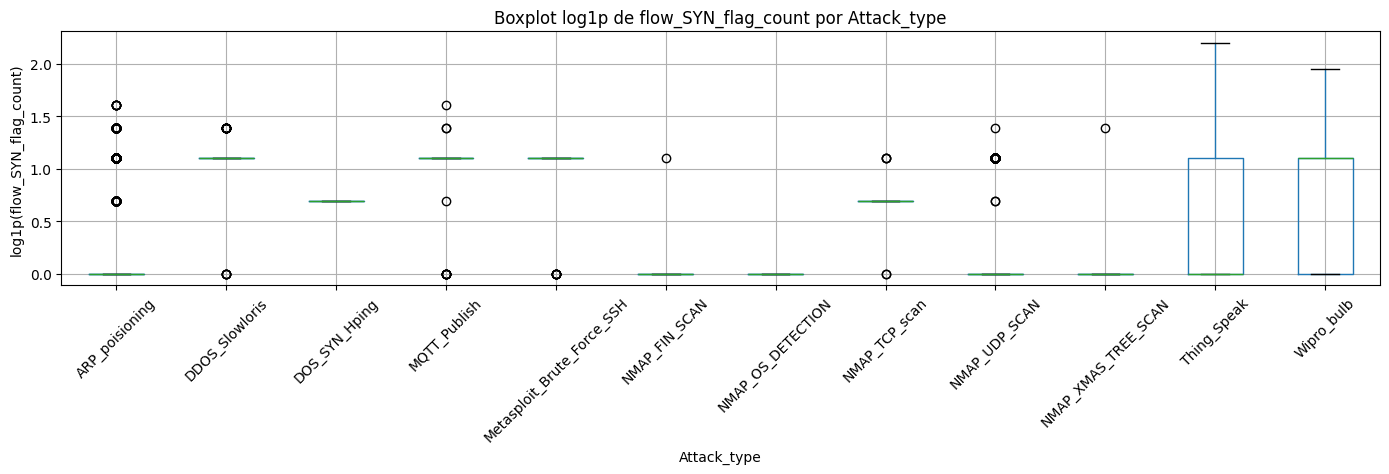

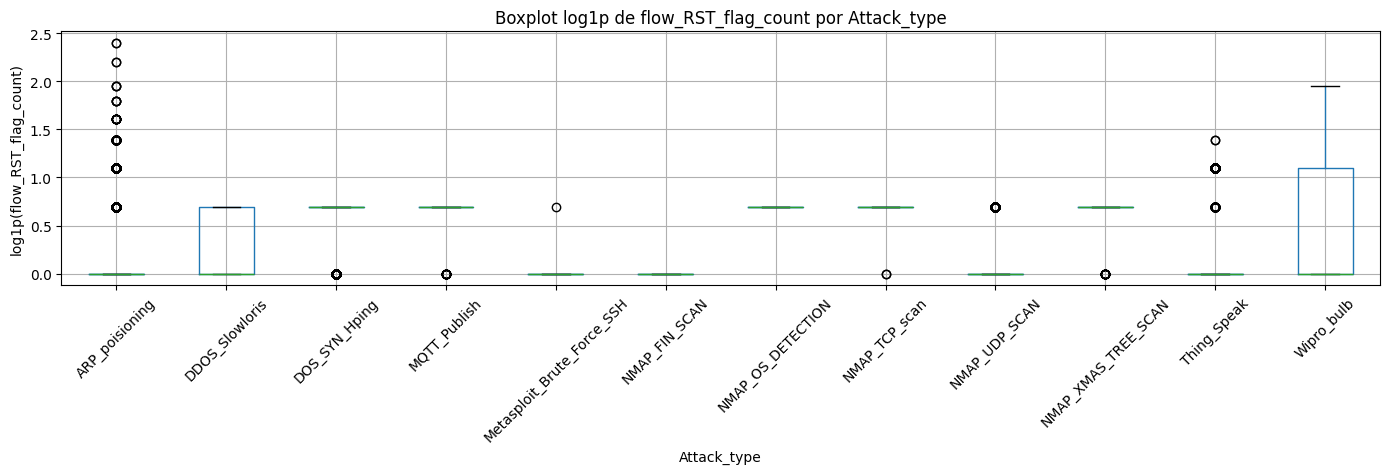

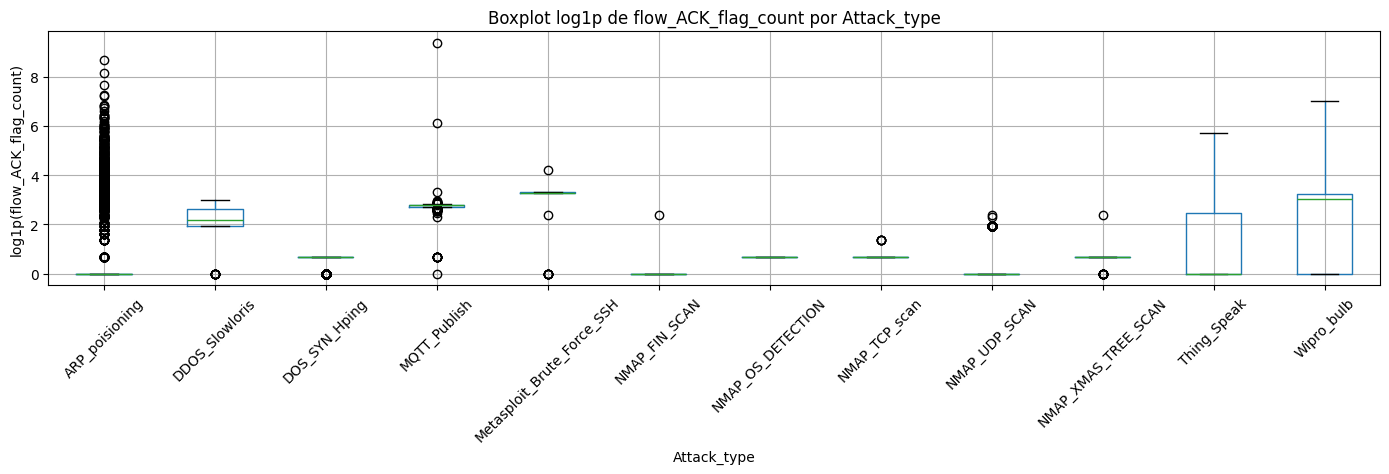

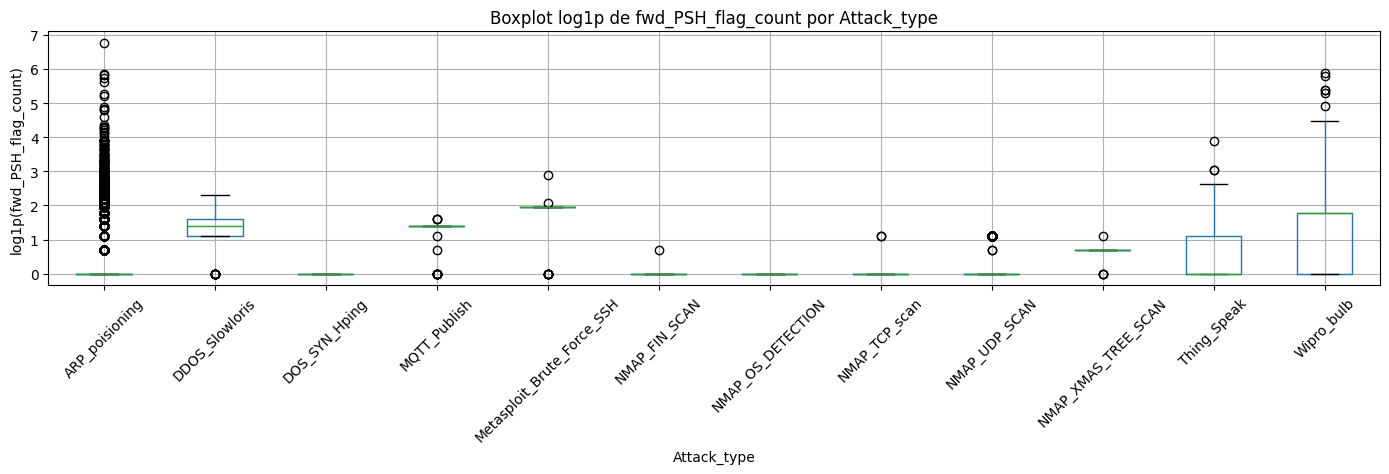

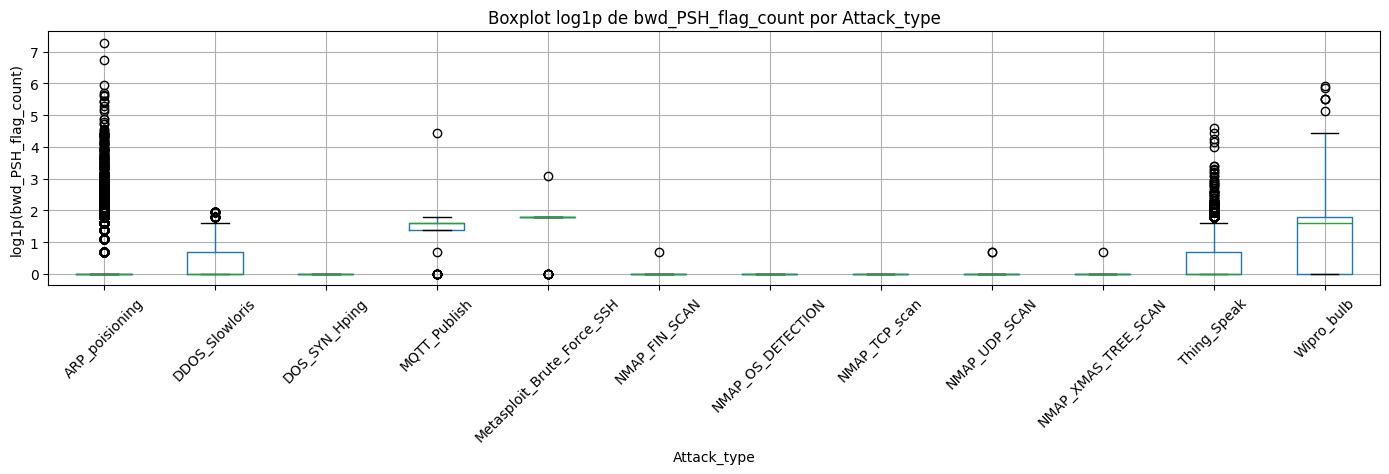

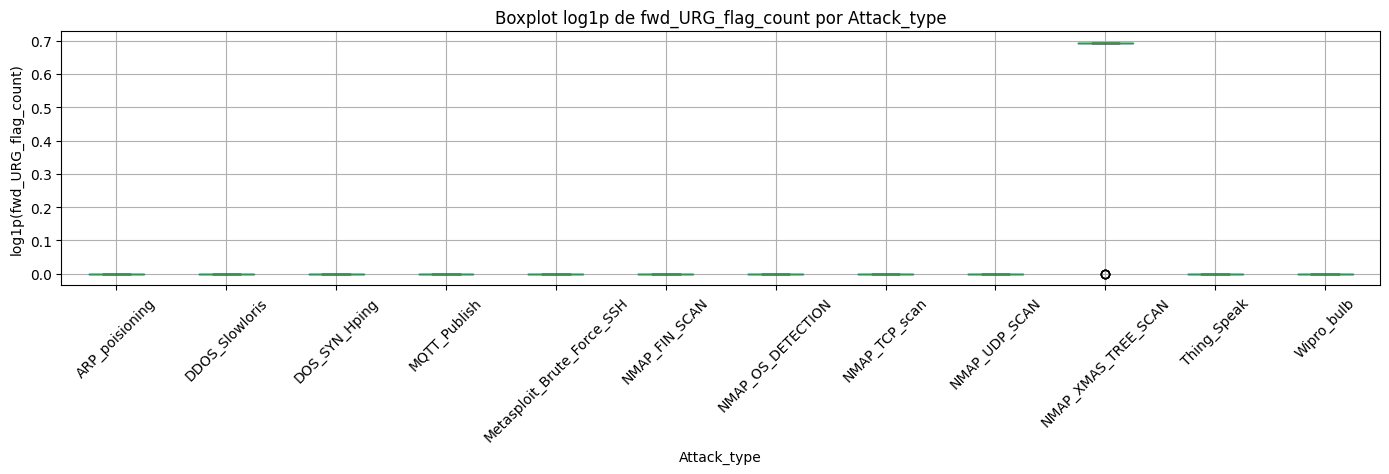

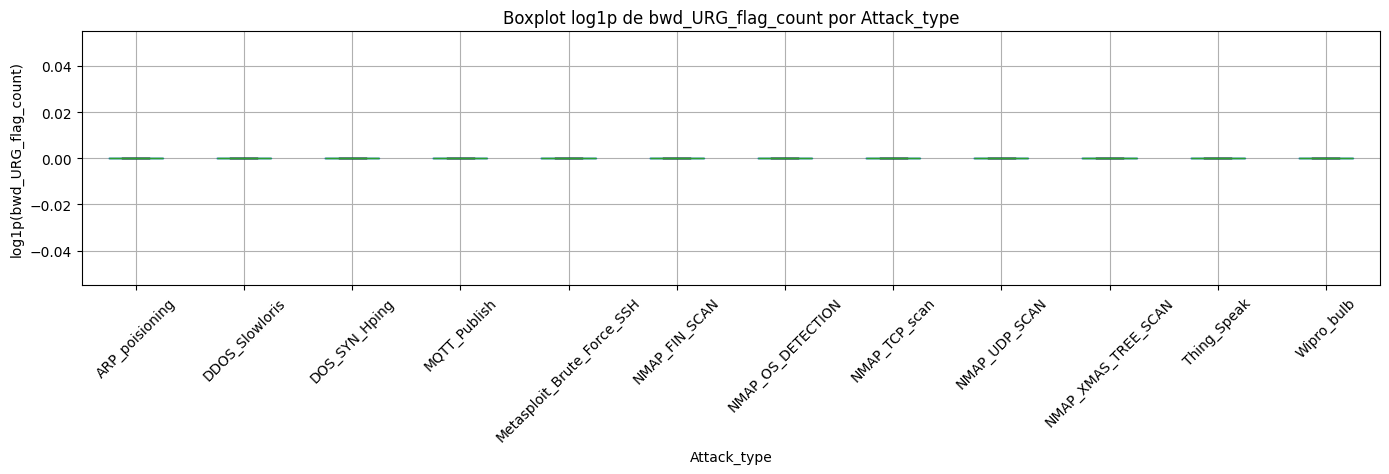

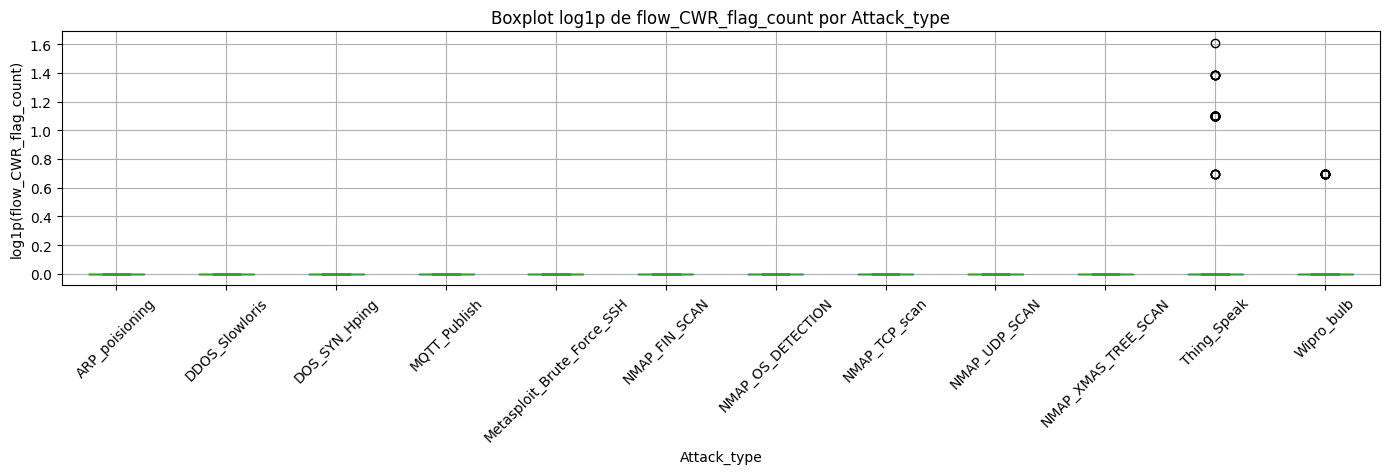

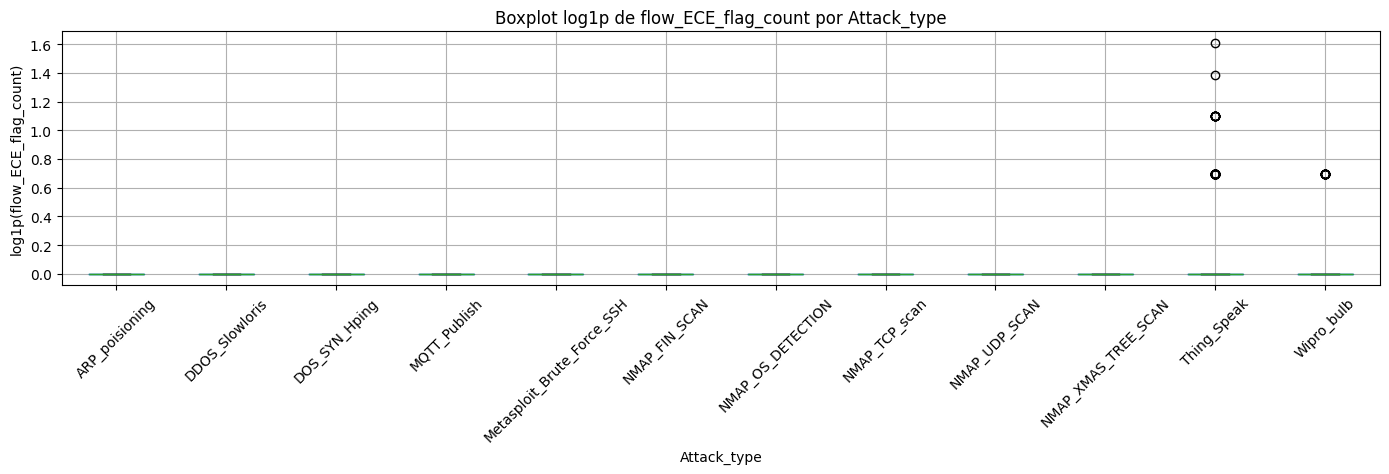

In [20]:
# Boxplots por flag. Se usa escala logarítmica con log1p para facilitar lectura.
for col in flags_tcp:
    temp = df[["Attack_type", col]].copy()
    temp[col] = np.log1p(temp[col])
    ax = temp.boxplot(column=col, by="Attack_type", figsize=(14, 5), rot=45)
    plt.title(f"Boxplot log1p de {col} por Attack_type")
    plt.suptitle("")
    plt.xlabel("Attack_type")
    plt.ylabel(f"log1p({col})")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"boxplot_{col}.png"), dpi=300)
    plt.show()

In [21]:
# Flags que más aparecen por ataque
top_presence = []
for col in flags_tcp:
    s = presence_attack_type[col].sort_values(ascending=False)
    top_presence.append({
        "variable": col,
        "ataque_mayor_presencia": s.index[0],
        "presencia_max_%": s.iloc[0],
        "presencia_global_%": round((df[col] != 0).mean() * 100, 2),
    })

top_presence = pd.DataFrame(top_presence)
top_presence

,variable,ataque_mayor_presencia,presencia_max_%,presencia_global_%
0,flow_FIN_flag_count,NMAP_XMAS_TREE_SCAN,99.85,6.55
1,flow_SYN_flag_count,DOS_SYN_Hping,100.00,86.36
2,flow_RST_flag_count,NMAP_OS_DETECTION,100.00,78.43
3,flow_ACK_flag_count,NMAP_OS_DETECTION,100.00,81.69
4,fwd_PSH_flag_count,NMAP_XMAS_TREE_SCAN,99.85,10.16
5,bwd_PSH_flag_count,MQTT_Publish,99.64,8.09
6,fwd_URG_flag_count,NMAP_XMAS_TREE_SCAN,99.80,1.63
7,bwd_URG_flag_count,ARP_poisioning,0.00,0.00
8,flow_CWR_flag_count,Wipro_bulb,8.30,0.06
9,flow_ECE_flag_count,Wipro_bulb,8.30,0.06


## Conclusiones principales

- No aparece una clase `Normal` en el archivo cargado, por lo que no se puede comparar Normal vs Ataque. Se comparó por `Attack_type`.
- SYN aparece mucho, especialmente en `DOS_SYN_Hping`.
- RST aparece mucho en escaneos como `NMAP_OS_DETECTION`, `NMAP_TCP_scan` y `NMAP_XMAS_TREE_SCAN`.
- URG, CWR y ECE casi siempre son cero.
- Los flags más útiles para el modelo son SYN, ACK y RST; FIN es útil para ataques específicos; PSH puede ser complementario.